# Endeavoring to Understand Non-causal Behavior in Transient Source Estimation Problems - Technical Content

```{note}
This series of notebooks shows the technical work and code that was used to generate the findings for the ISMA 2026 conference paper of the same name. Consequently, there will be limited narrative content. Refer to the paper in the ISMA 2026 conference proceedings for more details and discussion.
``` 

The work in this series of notebooks is intended to demonstrate different scenarios that can cause apparent non-causalities in transient inverse source estimation (ISE) problems. These scenarios include:

- [Circular convolution error](circular_convolution.ipynb)
- [Non-causalities in frequency response functions](noncausal_frfs.ipynb) (FRFs), which are due to:
    - Band limited FRFs
    - Frequency dependent weighting
    - Regularization
- [Different methods for adjusting the frequency resolution of the FRFs](zero_padding.ipynb) (i.e., zero padding and interpolation)
- [Modeling errors](zero_padding.ipynb)

## Evaluated Inverse Method
This work evaluates how the apparent non-causalities effect a transient ISE technique that leverages frequency domain deconvolution (i.e., FRF matrix inversion). The basic algorithm is:

1. The responses are zero padded to avoid circular convolution errors (this will be discussed in more details [here](circular_convolution.ipynb))
2. The zero padded responses are converted to the frequency domain via a discrete Fourier transform (DFT)
3. The frequency resolution of the FRFs is adjusted to match the frequency resolution of the zero padded responses
4. The sources are estimated in the frequency domain using FRF matrix inversion, where any number of inverse methods could be used
5. The frequency domain sources are converted back to the time domain and the zero padded time segments are trimmed off

## General Process for the Study
This work uses a circular ISE problem with the beam system that is generated below. The general process for the ISE problem is:

1. Truth forces are applied to the beam and the responses are computed with numerical integration
2. FRFs are computed between the truth force degrees of freedom (DOFs) and the appropriate response DOFs
3. The forces are estimated using the FRFs and computed responses (with the algorithm that was described above)

## Example Beam System
The different scenarios in this work will be evaluated with an example problem that uses a finite element model of the beam system that is shown in the image below. The beam is modeled using Euler-Bernoulli beam elements with standard functions in SDynPy, where each dot in the image represents a node in the model. The beam is connected to the ground via translating and torsion springs (although the torsion springs aren't sketched in the image). The red arrows (below the beam) are the excitation DOFs and the blue arrows (above the beam) are the response DOFs that are used in the force estimation. 

```{note}
The beam nodes are labeled 101-109 from left to right. The shear direction (vertical on the page) is Z+ and the torsion direction is RY+. 
```

```{figure} images/beam_system.svg
:alt: Beam System for Causality Study
:align: center
```

In [1]:
import sdynpy as sdpy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
plt.rcParams.update({'font.size':10,
                     'font.family':'Times New Roman'})

### Nominal Beam System
The nominal beam system will be used in most of the scenarios in this work, where the nominal beam properties are:

- Beam length - 4 m
- Beam width - 0.02 m
- Beam height - 0.015 m
- Material properties - aluminum
- Translating spring stiffness to ground - 100 N/m
- Torsion spring stiffness to ground - 100 Nm/radian
- Beam damping ratio - 4% modal damping, which is added to the free-free beam (without the springs to ground)

In [2]:
youngs_modulus = 69.8e9 # pascals
density = 2700 # kg/m^3
poissons_ratio = 0.33

beam_length = 4 # meters
beam_width = 0.02 # meters
beam_height = 0.015 # meters
number_nodes = 9

beam_stiffness, beam_mass = sdpy.beam.beamkm_2d(beam_length, beam_width, beam_height, 
                                                number_nodes, youngs_modulus, density, 
                                                poissons_ratio, axial=False)

The beam model is being saved into a SDynPy `System` object, for ease of use. A standard function is used to add the modal damping before the ground springs are put into the model. 

In [3]:
beam_coordinate = sdpy.coordinate_array(node=np.arange(number_nodes)+101, direction=[3,5], 
                                        force_broadcast=True)

nominal_beam_system = sdpy.System(beam_coordinate, beam_mass, beam_stiffness)
nominal_beam_system.assign_modal_damping(0.04)

The ground springs are included in the model by simply adding the ground spring stiffness's to the stiffness matrix.

In [4]:
translating_spring = 100 #N/m
torsion_spring = 100 #Nm/rad

In [5]:
nominal_beam_system.stiffness[0,0] += translating_spring # N/m, translating spring to ground on left side
nominal_beam_system.stiffness[1,1] += torsion_spring # Nm/rad, torsion spring to ground on left side 

nominal_beam_system.stiffness[-2,-2] += translating_spring # N/m, translating spring to ground on right side
nominal_beam_system.stiffness[-1,-1] += torsion_spring # Nm/rad, torsion spring to ground on right side 

### Creating the Beam Geometry
The beam geometry is being created for completeness, but will not be used in this work. 

In [6]:
beam_locations = np.array([[0,   0, 0], 
                           [0.5, 0, 0],
                           [1,   0, 0], 
                           [1.5, 0, 0],
                           [2,   0, 0], 
                           [2.5, 0, 0],
                           [3,   0, 0], 
                           [3.5, 0, 0],
                           [4,   0, 0]], dtype=float)

system_cs = sdpy.geometry.coordinate_system_array()

beam_nodes = sdpy.geometry.node_array(id=np.unique(beam_coordinate.node), 
                                      coordinate=beam_locations)
beam_fem = sdpy.geometry.Geometry(node=beam_nodes, coordinate_system=system_cs)

beam_fem.add_traceline(np.unique(beam_coordinate.node))

(sec:perturbed_beam_system)=
### Perturbed Beam System
Modeling errors are added to the nominal beam system by perturbing the natural frequencies and damping ratios of the beam modes via multiplication by a random number. The random number generator (the `freq_rng` and `damping_rng` objects) are created with a seed value to get repeatable results over multiple runs. 

```{note}
The scale in the random number generators was tuned to produce frequency and damping errors that are roughly representative of what the author has seen in test-to-analysis comparisons and test-to-test variation. 
```
```{warning}
The random perturbations in this model were used because they were easy to implement. However, they may not be physically representative since the perturbations are independent of one another (e.g., a stiffness change in one mode does not influence a stiffness change in another mode).
```
Programmatically, the system is perturbed by first computing the modal properties of the system with the `eigensolution` method.

In [7]:
nominal_modes = nominal_beam_system.eigensolution()

The natural frequency and damping errors are then are then applied directly to a copy of the `ShapeArray` for the nominal beam. 

In [8]:
freq_rng = np.random.default_rng(seed=5641)

perturbed_modes = nominal_modes.copy()
perturbed_modes.frequency *= freq_rng.normal(loc=1, scale=0.1, 
                                             size=nominal_modes.shape[0])

In [9]:
damping_rng = np.random.default_rng(seed=1761)

perturbed_modes.damping *= damping_rng.normal(loc=1, scale=0.5, 
                                              size=nominal_modes.shape[0])

The perturbed beam system modes are converted back to a SDynPy `System` object for ease of use. 

In [10]:
perturbed_beam_system = perturbed_modes.system()

### Comparing the Nominal and Perturbed Modal Properties
The natural frequency and damping errors are shown in the shape comparison table and bar plot that is shown below. 

In [11]:
print(sdpy.shape.shape_comparison_table(nominal_modes, 
                                  perturbed_modes,
                                  percent_error_format='{:0.2f}%'))

  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  Damp 1  Damp 2  Damp Error  MAC
     1         1.14         1.20      -4.85%   0.12%   0.20%     -40.63%  100
     2         2.27         2.15       5.42%   0.06%   0.06%       3.84%  100
     3         6.10         6.39      -4.43%   3.21%   3.19%       0.67%  100
     4        14.51        14.95      -2.96%   3.73%   0.88%     323.29%  100
     5        27.46        27.11       1.31%   3.86%   1.87%     107.16%  100
     6        44.92        36.95      21.57%   3.92%   2.87%      36.63%  100
     7        67.00        70.17      -4.52%   3.95%   2.74%      44.18%  100
     8        93.83        95.53      -1.78%   3.96%   2.04%      94.44%  100
     9       124.05       135.79      -8.65%   3.97%   4.41%      -9.99%  100
    10       173.53       191.62      -9.44%   3.98%   3.63%       9.59%  100
    11       218.81       196.21      11.52%   3.98%   5.74%     -30.73%  100
    12       275.70       284.73      -3.17%   3.98%   4.35%    

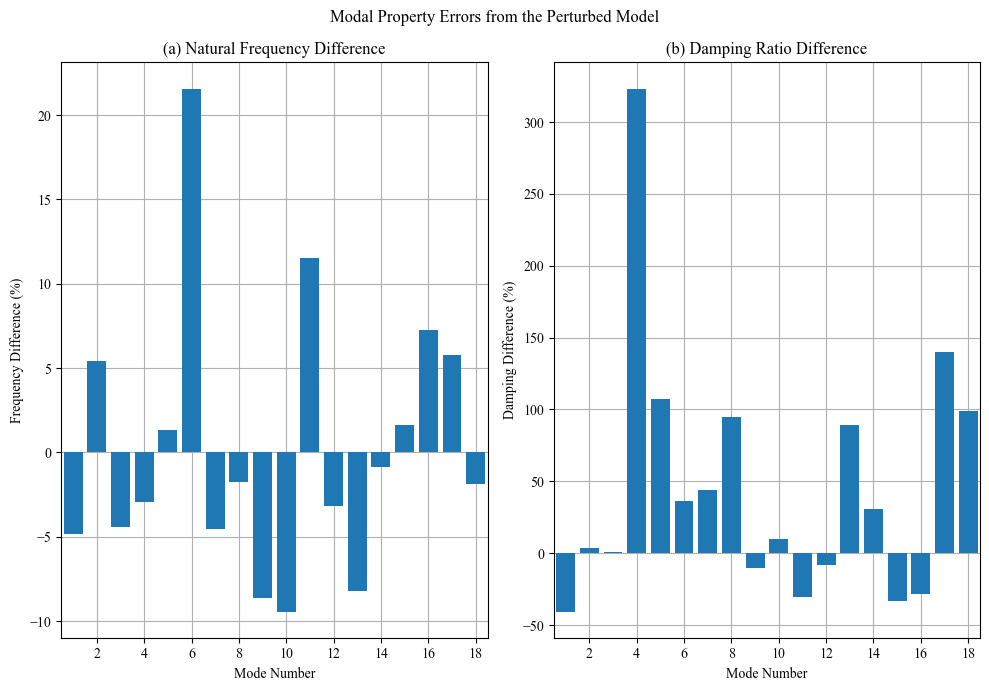

In [12]:
fig, ax = plt.subplots(1,2,figsize=(10,7))

ax[0].bar(np.arange(18)+1, 100*(nominal_modes.frequency-perturbed_modes.frequency)/perturbed_modes.frequency, zorder=3)
ax[0].set_xlabel('Mode Number'); ax[0].set_xlim(left=0.5, right=18.5); ax[0].set_ylabel('Frequency Difference (%)')
ax[0].set_title('(a) Natural Frequency Difference'); ax[0].grid(zorder=0)

ax[1].bar(np.arange(18)+1, 100*(nominal_modes.damping-perturbed_modes.damping)/perturbed_modes.damping, zorder=3)
ax[1].set_xlabel('Mode Number'); ax[1].set_xlim(left=0.5, right=18.5); ax[1].set_ylabel('Damping Difference (%)')
ax[1].set_title('(b) Damping Ratio Difference'); ax[1].grid(zorder=0)

fig.suptitle('Modal Property Errors from the Perturbed Model')
fig.tight_layout()

## Creating the Truth Pulse
A simple half-sine pulse is used in this study, where the same pulse is applied to both excitation DOFs, but at different times. There are two pulses used in this work: 

- __Low frequency pulse__ - this pulse has a width of 0.01 seconds, which was chosen to limit the excitation bandwidth for an ISE problem with a band limited representation of the system  
- __High frequency pulse__ - this pulse has a width of 0.001, which was chosen to excite all the modes in the system

The pulses (and resulting responses) are being sampled at 10,000 Hz to have a reasonable (~6x) oversample of the modes in the system. The total signal duration and time between pulses was chosen to be relatively short, with one pulse being very close to the end of the time frame to accentuate errors (especially circular convolution error) in the ISE problem. 

An initial review of the transient ISE results indicated that there were significant issues with the FRF matrix conditioning at low frequencies and that these issues were especially significant when estimating the low frequency pulses. Consequently, a high pass filter is being applied to the low frequency pulses to eliminate the low frequency content from the corresponding ISE problem. The low frequency conditioning did not seem to be a significant issue in the ISE problem with the high frequency pulses, so the filter was not applied to the high frequency pulses. 

In [13]:
Fs = 10000 #Hz
T = 2 #seconds
time = np.arange(Fs*T+1)/Fs

### Low Frequency Pulse

In [14]:
# Making the basic pulse that will be applied at different times for the different force DOFs
low_freq_pulse_width = 0.01 #seconds
low_freq_pulse_time = np.arange(Fs*low_freq_pulse_width+1)/Fs
low_freq_pulse = np.sin(((2*np.pi)/(low_freq_pulse_width*2))*low_freq_pulse_time)

low_freq_pulse_ordinate = np.zeros((2,time.shape[0]), dtype=float)
low_freq_pulse_ordinate[0, np.arange(low_freq_pulse_time.shape[0])+3000] = low_freq_pulse
low_freq_pulse_ordinate[1, np.arange(low_freq_pulse_time.shape[0])+15000] = low_freq_pulse

The high pass filter was a 20th order butterworth filter with a cutoff frequency of 10 Hz. This filter is built with second order sections and is applied to the pulses with the typical zero phase forward-backward approach. 

In [15]:
sos_filt = butter(20, 10, btype='high', output='sos', fs=Fs)
low_freq_pulse_ordinate = sosfiltfilt(sos_filt, low_freq_pulse_ordinate)

low_freq_pulse_excitation = sdpy.data_array(sdpy.data.FunctionTypes.TIME_RESPONSE, time, low_freq_pulse_ordinate, 
                                   sdpy.coordinate_array(string_array=['103Z+', '104Z+'])[...,np.newaxis])

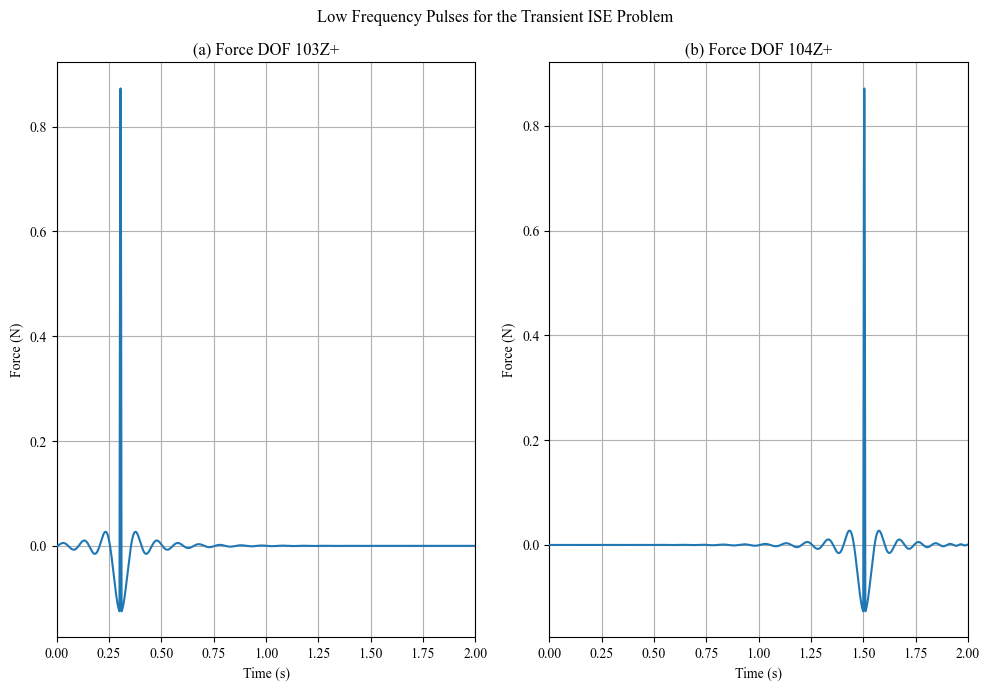

In [16]:
fig, ax = plt.subplots(1,2,figsize=(10,7))

ax[0].plot(low_freq_pulse_excitation[0].abscissa, low_freq_pulse_excitation[0].ordinate, zorder=3)
ax[0].set_xlabel('Time (s)'); ax[0].set_xlim(left=0, right=2); ax[0].set_ylabel('Force (N)')
ax[0].set_title('(a) Force DOF {:}'.format(low_freq_pulse_excitation[0].response_coordinate.string_array())); ax[0].grid(zorder=0)

ax[1].plot(low_freq_pulse_excitation[1].abscissa, low_freq_pulse_excitation[1].ordinate, zorder=3)
ax[1].set_xlabel('Time (s)'); ax[1].set_xlim(left=0, right=2); ax[1].set_ylabel('Force (N)')
ax[1].set_title('(b) Force DOF {:}'.format(low_freq_pulse_excitation[1].response_coordinate.string_array())); ax[1].grid(zorder=0)

fig.suptitle('Low Frequency Pulses for the Transient ISE Problem')
fig.tight_layout()

The plot below shows the frequency spectrum for the low frequency pulse excitation (from a single DOF). This shows that the low frequency pulse has significant roll-off (>20 dB) at 150 Hz. 

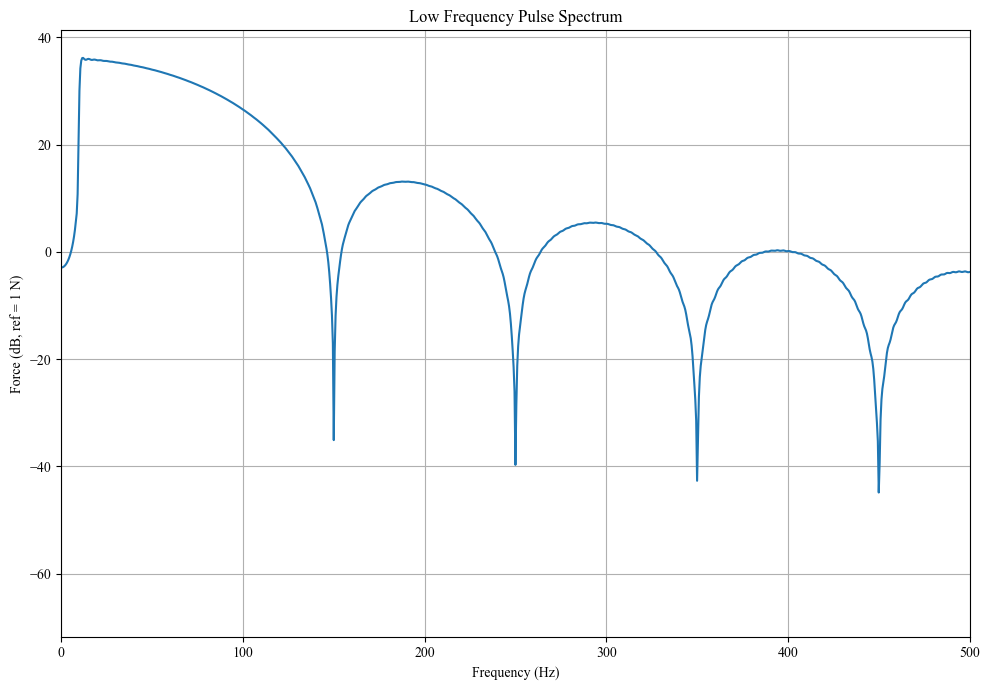

In [25]:
plt.figure(figsize=(10,7))
plt.plot(low_freq_pulse_excitation.fft()[0].abscissa, 
         20*np.log10(np.abs(low_freq_pulse_excitation.fft()[0].ordinate)))
plt.xlabel('Frequency (Hz)'); plt.ylabel('Force (dB, ref = 1 N)')
plt.title('Low Frequency Pulse Spectrum'); plt.grid(); plt.xlim(left=0, right=500)
plt.tight_layout()

### High Frequency Pulse
A high pass filter is not applied to the high frequency pulse, since the conditioning issues did not seem to influence the ISE problem with the high frequency pulse as much as with the low frequency pulse. 

In [18]:
# Making the basic pulse that will be applied at different times for the different force DOFs
high_freq_pulse_width = 0.001 #seconds
high_freq_pulse_time = np.arange(Fs*high_freq_pulse_width+1)/Fs
high_freq_pulse = np.sin(((2*np.pi)/(high_freq_pulse_width*2))*high_freq_pulse_time)

high_freq_pulse_ordinate = np.zeros((2,time.shape[0]), dtype=float)
high_freq_pulse_ordinate[0, np.arange(high_freq_pulse_time.shape[0])+3000] = high_freq_pulse
high_freq_pulse_ordinate[1, np.arange(high_freq_pulse_time.shape[0])+15000] = high_freq_pulse

high_freq_pulse_excitation = sdpy.data_array(sdpy.data.FunctionTypes.TIME_RESPONSE, time, high_freq_pulse_ordinate, 
                                   sdpy.coordinate_array(string_array=['103Z+', '104Z+'])[...,np.newaxis])

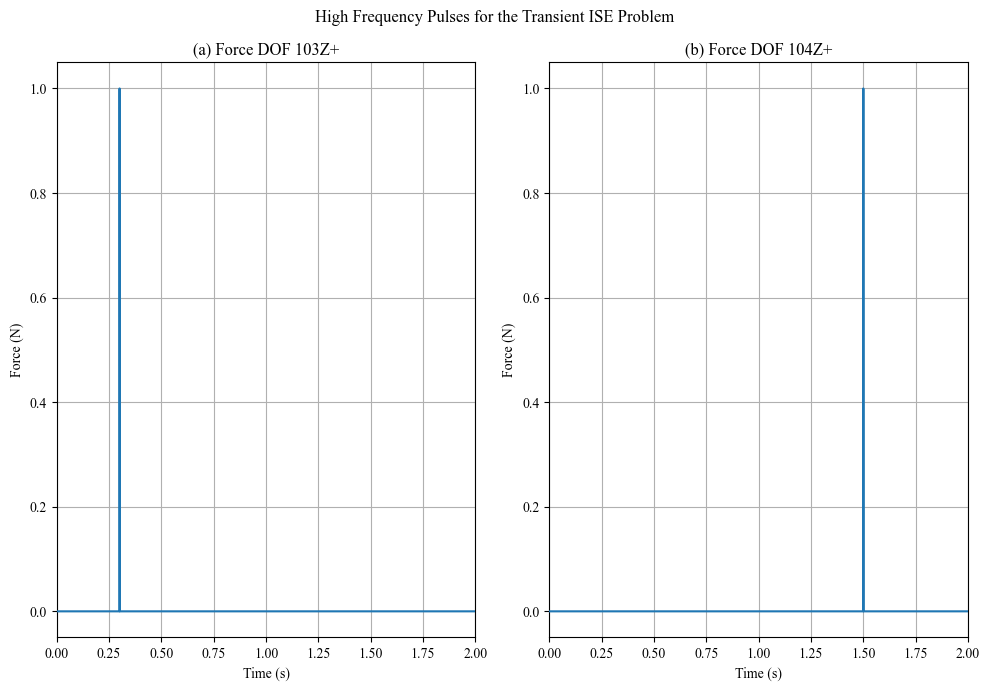

In [26]:
fig, ax = plt.subplots(1,2,figsize=(10,7))

ax[0].plot(high_freq_pulse_excitation[0].abscissa, high_freq_pulse_excitation[0].ordinate, zorder=3)
ax[0].set_xlabel('Time (s)'); ax[0].set_xlim(left=0, right=2); ax[0].set_ylabel('Force (N)')
ax[0].set_title('(a) Force DOF {:}'.format(low_freq_pulse_excitation[0].response_coordinate.string_array())); ax[0].grid(zorder=0)

ax[1].plot(high_freq_pulse_excitation[1].abscissa, high_freq_pulse_excitation[1].ordinate, zorder=3)
ax[1].set_xlabel('Time (s)'); ax[1].set_xlim(left=0, right=2); ax[1].set_ylabel('Force (N)')
ax[1].set_title('(b) Force DOF {:}'.format(low_freq_pulse_excitation[1].response_coordinate.string_array())); ax[1].grid(zorder=0)

fig.suptitle('High Frequency Pulses for the Transient ISE Problem')
fig.tight_layout()

The plot below shows the frequency spectrum for the high frequency pulse excitation (from a single DOF). This shows that the high frequency pulse has significant roll-off (>20 dB) at 1,500 Hz. 

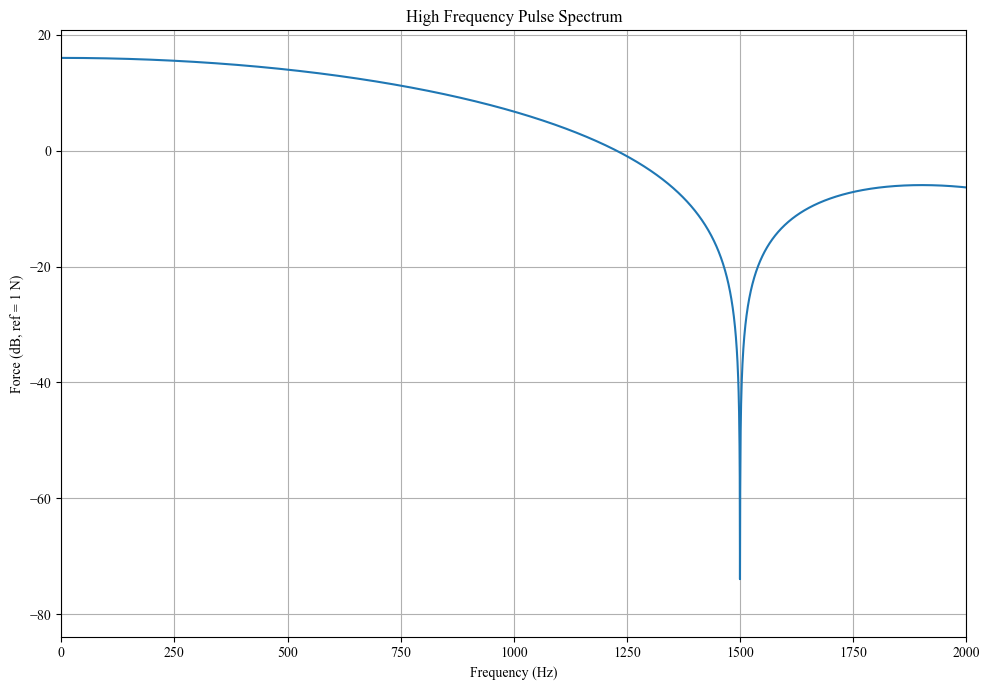

In [20]:
plt.figure(figsize=(10,7))
plt.plot(high_freq_pulse_excitation.fft()[0].abscissa, 
         20*np.log10(np.abs(high_freq_pulse_excitation.fft()[0].ordinate)))
plt.xlabel('Frequency (Hz)'); plt.ylabel('Force (dB, ref = 1 N)')
plt.title('High Frequency Pulse Spectrum'); plt.grid(); plt.xlim(left=0, right=2000)
plt.tight_layout()

## Computing the Response of the Beam System without Errors
The beam system response is computed using `time_integrate` method in SDynPy, which uses a state space formulation. The displacement derivative is set to two (denoted bt the `2` in the `responses` kwarg), meaning that the returned responses will be acceleration. The `integration_oversample` kwarg was set to ten to prevent any issues in the numerical integration. Lastly, the responses are only computed for the DOFs that will be used in the inverse problem, as noted above. 

```{note}
The responses for the ISE problem are what is directly output from the time integration. No filter is being applied to the responses. 
```

In [21]:
response_coordinate = sdpy.coordinate_array(node=[102,104,106,108], direction=3)
low_freq_truth_responses = nominal_beam_system.time_integrate(low_freq_pulse_excitation, 
                                                     responses={2:response_coordinate}, 
                                                     integration_oversample=10)

high_freq_truth_responses = nominal_beam_system.time_integrate(high_freq_pulse_excitation, 
                                                     responses={2:response_coordinate}, 
                                                     integration_oversample=10)

A sample response is shown in the figure below. It can be seen that there are distinct responses for the different pulses and that there is plenty of extra time between the pulses for ring down from the first pulse. 

```{note}
The response to the second (low frequency) pulse was cutoff before it fully decayed to zero in order to accentuate circular convolution errors.
```

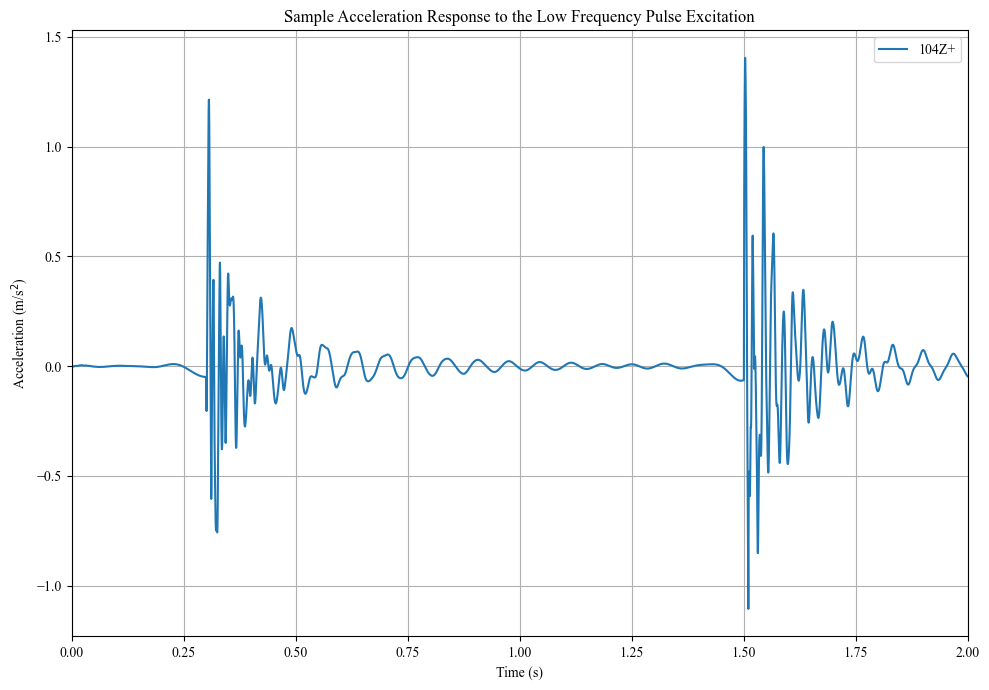

In [22]:
plt.figure(figsize=(10,7))
plt.plot(low_freq_truth_responses[1].abscissa, low_freq_truth_responses[1].ordinate, 
         label=low_freq_truth_responses[1].response_coordinate)
plt.xlabel('Time (s)'); plt.ylabel('Acceleration (m/s$^2$)')
plt.title('Sample Acceleration Response to the Low Frequency Pulse Excitation')
plt.xlim(left=0, right=2); plt.grid(); plt.legend()
plt.tight_layout()

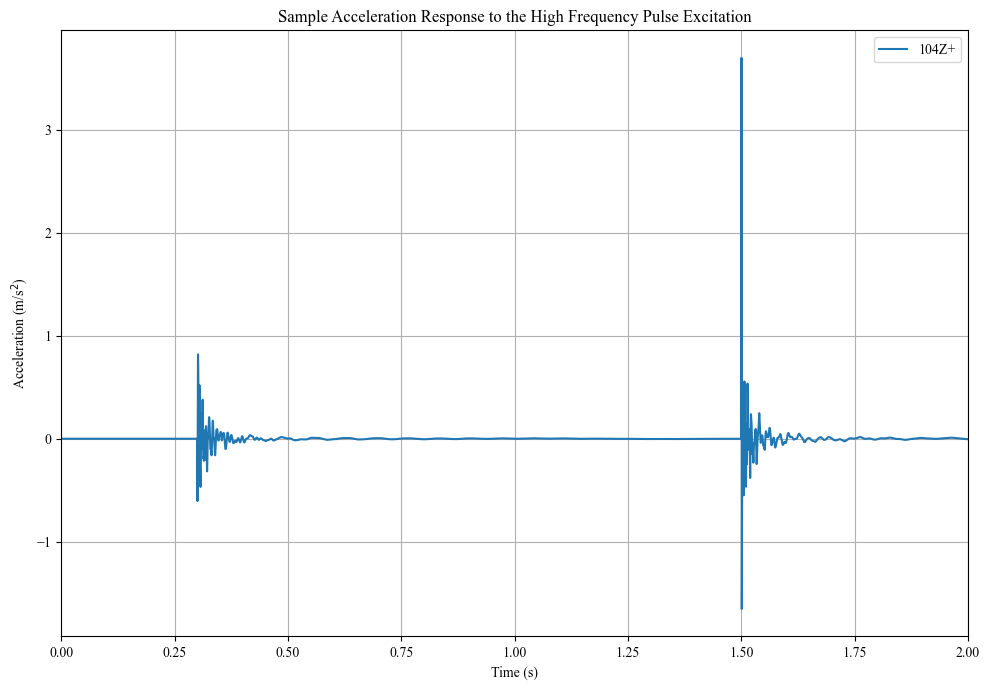

In [23]:
plt.figure(figsize=(10,7))
plt.plot(high_freq_truth_responses[1].abscissa, high_freq_truth_responses[1].ordinate, 
         label=high_freq_truth_responses[1].response_coordinate)
plt.xlabel('Time (s)'); plt.ylabel('Acceleration (m/s$^2$)')
plt.title('Sample Acceleration Response to the High Frequency Pulse Excitation')
plt.xlim(left=0, right=2); plt.grid(); plt.legend()
plt.tight_layout()

## Saving the Beam Data
The various beam data is saved off so it can be recalled in other notebooks, which will evaluate the different scenarios that result in causality issues. 

In [24]:
#nominal_beam_system.save(r'./system_data/nominal_beam_system.npz')
#perturbed_beam_system.save(r'./system_data/perturbed_beam_system.npz')
#beam_fem.save(r'./system_data/beam_system_geometry.npz')
#low_freq_pulse_excitation.save(r'./system_data/low_freq_truth_pulse_excitation.npz')
#low_freq_truth_responses.save(r'./system_data/low_freq_truth_response.npz')
#high_freq_pulse_excitation.save(r'./system_data/high_freq_truth_pulse_excitation.npz')
#high_freq_truth_responses.save(r'./system_data/high_freq_truth_response.npz')